In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

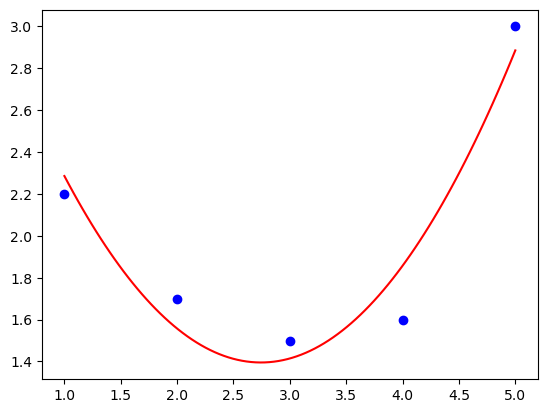

In [28]:
x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2.2, 1.7, 1.5, 1.6, 3.0])

poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

model = LinearRegression()
model.fit(x_poly, y)

x_new = np.linspace(1, 5, 100).reshape(-1, 1)
x_new_poly = poly.transform(x_new)
y_pred = model.predict(x_new_poly)

plt.scatter(x, y, color='blue')
plt.plot(x_new, y_pred, color='red')
plt.show()

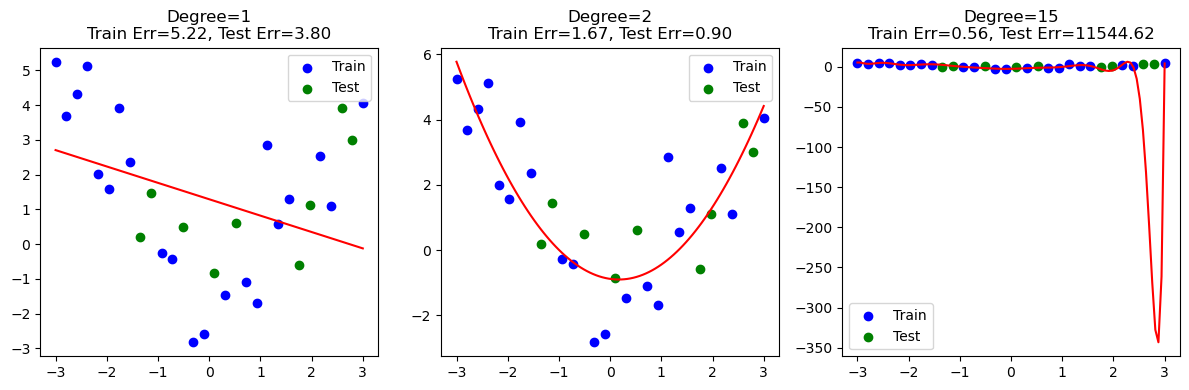

In [27]:
# 1. Create synthetic data (true function: y = 0.5x^2 + noise)
np.random.seed(42)
x = np.linspace(-3, 3, 30).reshape(-1, 1)
y = 0.5 * x**2 + np.random.randn(30, 1) * 1.5  # add noise

# 2. Split into train/test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# 3. Try different polynomial degrees
degrees = [1, 2, 15]
plt.figure(figsize=(12, 4))

for i, d in enumerate(degrees, 1):
    # Create polynomial features
    poly = PolynomialFeatures(degree=d)
    x_train_poly = poly.fit_transform(x_train)
    x_test_poly = poly.transform(x_test)

    # Fit model
    model = LinearRegression()
    model.fit(x_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(x_train_poly)
    y_test_pred = model.predict(x_test_poly)

    # Errors
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    # Plot
    plt.subplot(1, 3, i)
    plt.scatter(x_train, y_train, color="blue", label="Train")
    plt.scatter(x_test, y_test, color="green", label="Test")
    x_plot = np.linspace(-3, 3, 100).reshape(-1, 1)
    plt.plot(x_plot, model.predict(poly.transform(x_plot)), color="red")
    plt.title(f"Degree={d}\nTrain Err={train_error:.2f}, Test Err={test_error:.2f}")
    plt.legend()

plt.tight_layout()
plt.show()